# Logistic Regression

# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load dataset

In [3]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


# Check dataset

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (768, 9)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


# Check missing values

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Statistical information

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Check target values

In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Select input and output

In [9]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


# Feature scaling

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create model

In [12]:
model = LogisticRegression()

# Train model

In [13]:
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


# Make predictions

In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 1 0]


# Compare actual and predicted

In [15]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result.head(15)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,1
9,0,1


# Accuracy

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.7727272727272727
Accuracy Percentage: 77.27272727272727 %


# Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[83 16]
 [19 36]]


# Confusion Matrix visualization

In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[83 16]
 [19 36]]


# Classification Report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



# Predict a new patient

In [21]:
new_patient = [[2, 120, 70, 20, 79, 25, 0.5, 30]]

new_patient_scaled = scaler.transform(new_patient)

prediction = model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Patient is predicted to have diabetes")
else:
    print("Patient is predicted NOT to have diabetes")

Patient is predicted NOT to have diabetes


C:\Users\Shri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Probability

In [22]:
probability = model.predict_proba(new_patient_scaled)

print("Probability of No Diabetes:", probability[0][0])
print("Probability of Diabetes:", probability[0][1])

Probability of No Diabetes: 0.9064007181741517
Probability of Diabetes: 0.09359928182584831


# Visualization

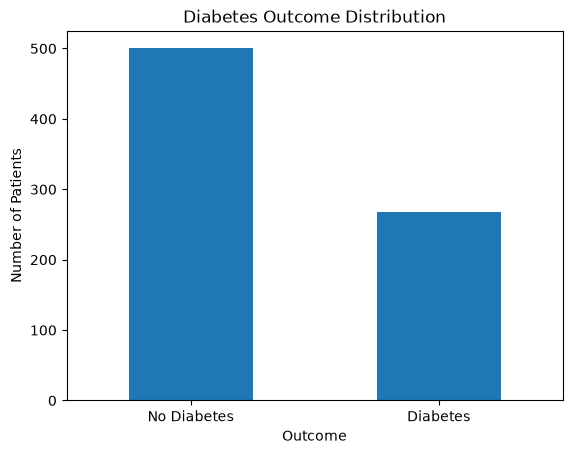

In [24]:
# Diabetes Outcome Distribution

df['Outcome'].value_counts().sort_index().plot(kind='bar')

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)

plt.show()

# Glucose vs Outcome

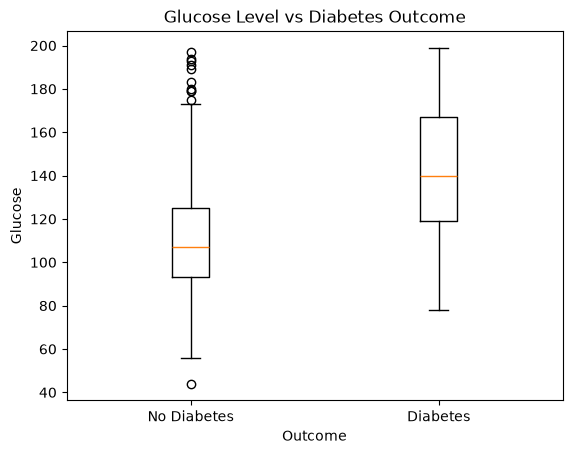

In [26]:
plt.boxplot([
    df[df['Outcome'] == 0]['Glucose'],
    df[df['Outcome'] == 1]['Glucose']
])

plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.xticks([1, 2], ["No Diabetes", "Diabetes"])

plt.show()